In [383]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [384]:
df = pd.read_csv(
    "../data/processed/bitcoin_features.csv"
)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_return,Volatility,MA7,...,RSI,EMA12,EMA26,MACD,MACD_ratio,Return_7D,Return_30D,BB_upper,BB_lower,BB_position
0,2014-12-15,351.360992,351.815002,344.933990,345.345001,345.345001,17264200,-0.017879,0.021259,349.426426,...,27.102635,356.422929,362.574433,-6.151504,-0.017813,-0.045768,-0.081854,393.588756,341.097908,0.080911
1,2014-12-16,345.673004,345.859009,327.062012,327.062012,327.062012,30864900,-0.052941,0.022171,345.832572,...,19.939262,351.905865,359.943883,-8.038018,-0.024576,-0.071424,-0.156800,394.254478,336.377521,-0.160954
2,2014-12-17,326.855011,333.954010,315.152008,319.776001,319.776001,37567900,-0.022277,0.022366,342.034145,...,19.724827,346.962809,356.968485,-10.005676,-0.031290,-0.076766,-0.174576,395.235210,330.887990,-0.172688
3,2014-12-18,319.785004,323.709015,304.231995,311.395996,311.395996,39173000,-0.026206,0.022178,336.447000,...,19.102052,341.490992,353.592745,-12.101753,-0.038863,-0.111582,-0.170049,397.871207,323.998526,-0.170598
4,2014-12-19,311.178986,318.532990,306.769012,317.842987,317.842987,23823100,0.020704,0.022410,331.489999,...,18.406462,337.852837,350.944614,-13.091777,-0.041189,-0.098425,-0.164791,398.204859,319.484074,-0.020847


# Predicting Bitcoin Direction

Objective:

Investigate whether technical indicators can predict future Bitcoin price movement.

In [385]:
df["Target"]=(df["Close"].shift(-1)>df["Close"]).astype(int)
df["target_7D"]=(df["Close"].shift(-7)>df["Close"]).astype(int)

In [386]:
df["Target"].tail(10)

4181    0
4182    0
4183    1
4184    0
4185    0
4186    0
4187    0
4188    0
4189    0
4190    0
Name: Target, dtype: int64

In [387]:
df["Target"].value_counts()

Target
1    2199
0    1992
Name: count, dtype: int64

In [388]:
df_ml=df.dropna().copy()
df_ml.shape

(4191, 33)

In [389]:
corr=df_ml[["Target","MACD"]].corr()
print(corr)

         Target     MACD
Target  1.00000  0.00317
MACD    0.00317  1.00000


In [390]:
corr=df_ml[["Target","MACD_ratio"]].corr()
print(corr)

              Target  MACD_ratio
Target      1.000000    0.024573
MACD_ratio  0.024573    1.000000


In [391]:
corr=df[["Return_7D","Return_30D","Target"]].corr()
print(corr)

            Return_7D  Return_30D    Target
Return_7D    1.000000    0.505082 -0.002289
Return_30D   0.505082    1.000000  0.015940
Target      -0.002289    0.015940  1.000000


In [392]:
corr=df_ml[["Target","BB_position"]].corr()
print(corr)

               Target  BB_position
Target       1.000000     0.019998
BB_position  0.019998     1.000000


In [393]:
features=["Daily_return","Volatility","RSI","Close_vs_MA30_ratio","MA7_vs_MA30_ratio"]

In [394]:
X=df_ml[features]
Y=df_ml["Target"]
Z=df_ml["target_7D"]
print(X.head())
print()
print(Y.head())
print()
print(Z.head())

   Daily_return  Volatility        RSI  Close_vs_MA30_ratio  MA7_vs_MA30_ratio
0     -0.017879    0.021259  27.102635             0.940115           0.951226
1     -0.052941    0.022171  19.939262             0.895285           0.946667
2     -0.022277    0.022366  19.724827             0.880776           0.942083
3     -0.026206    0.022178  19.102052             0.862748           0.932154
4      0.020704    0.022410  18.406462             0.885740           0.923771

0    0
1    0
2    0
3    1
4    1
Name: Target, dtype: int64

0    0
1    1
2    1
3    1
4    1
Name: target_7D, dtype: int64


In [395]:
split=int(len(df_ml)*0.8)
X_train=X[:split]
X_test=X[split:]
Y_train=Y[:split]
Y_test=Y[split:]
Z_train=Z[:split]
Z_test=Z[split:]

In [396]:
print(X_train.shape)
print(X_test.shape)

(3352, 5)
(839, 5)


In [397]:
model1=LogisticRegression(max_iter=1000)
model1.fit(X_train,Y_train)
model2=LogisticRegression(max_iter=1000)
model2.fit(X_train,Z_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [398]:
pred1=model1.predict(X_test)
pred2=model2.predict(X_test)

In [399]:
accuracy1=accuracy_score(Y_test,pred1)
print(accuracy1)
accuracy2=accuracy_score(Z_test,pred2)
print(accuracy2)

0.4922526817640048
0.5113230035756854


In [400]:
print(classification_report(Y_test,pred1))
print(classification_report(Z_test,pred2))

              precision    recall  f1-score   support

           0       0.47      0.08      0.14       421
           1       0.49      0.91      0.64       418

    accuracy                           0.49       839
   macro avg       0.48      0.49      0.39       839
weighted avg       0.48      0.49      0.39       839

              precision    recall  f1-score   support

           0       0.46      0.08      0.14       405
           1       0.52      0.91      0.66       434

    accuracy                           0.51       839
   macro avg       0.49      0.50      0.40       839
weighted avg       0.49      0.51      0.41       839



In [401]:
for feature, coef in zip(features,model1.coef_[0]):
  print(feature, coef)

Daily_return -1.5854249912916363
Volatility -0.1781744153830125
RSI 0.0068801275039943755
Close_vs_MA30_ratio -0.8277268587564811
MA7_vs_MA30_ratio 0.558385578485958


In [402]:
corr = df_ml[[
    "Daily_return",
    "Volatility",
    "RSI",
    "Close_vs_MA30_ratio",
    "MA7_vs_MA30_ratio",
    "target_7D"
]].corr()

print(corr["target_7D"].sort_values(ascending=False))

target_7D              1.000000
RSI                    0.060660
MA7_vs_MA30_ratio      0.042103
Close_vs_MA30_ratio    0.036254
Volatility             0.002403
Daily_return          -0.013400
Name: target_7D, dtype: float64


# Random Forest Classification

Unlike Logistic Regression, Random Forest can learn non-linear relationships and interactions between features.

Objective:
Determine whether a more powerful model can extract predictive signals from technical indicators.

In [403]:
rf=RandomForestClassifier(n_estimators=200,max_depth=5,random_state=42)
rf.fit(X_train,Y_train)
pred_rf=rf.predict(X_test)

In [404]:
rf_acc=accuracy_score(Y_test,pred_rf)
print(rf_acc)

0.5208581644815257


In [405]:
print(classification_report(Y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.53      0.38      0.44       421
           1       0.51      0.66      0.58       418

    accuracy                           0.52       839
   macro avg       0.52      0.52      0.51       839
weighted avg       0.52      0.52      0.51       839



In [406]:
importance_df=pd.DataFrame({"Feature":features,"Importance":rf.feature_importances_})
importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
0,Daily_return,0.227995
2,RSI,0.208961
1,Volatility,0.205802
4,MA7_vs_MA30_ratio,0.187874
3,Close_vs_MA30_ratio,0.169367


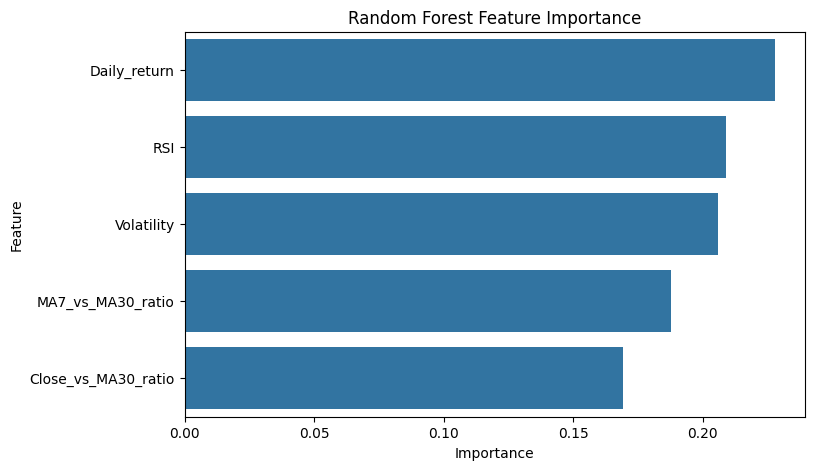

In [407]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.savefig(
    "../figures/rf_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# XGBoost Classifier

In [408]:
xgb=XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,random_state=42)
xgb.fit(X_train,Y_train)
pred_xgb=xgb.predict(X_test)

In [409]:
acc_xgb=accuracy_score(Y_test,pred_xgb)
print(acc_xgb)

0.5029797377830751


In [410]:
print(classification_report(Y_test,pred_xgb))

              precision    recall  f1-score   support

           0       0.51      0.45      0.47       421
           1       0.50      0.56      0.53       418

    accuracy                           0.50       839
   macro avg       0.50      0.50      0.50       839
weighted avg       0.50      0.50      0.50       839



In [411]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df

,Feature,Importance
3,Close_vs_MA30_ratio,0.216008
2,RSI,0.200772
0,Daily_return,0.197612
1,Volatility,0.193258
4,MA7_vs_MA30_ratio,0.192350


# WALK-FORWARD Backtesting

In [412]:
y_pred=rf.predict(X_test)

In [413]:
backtest=pd.DataFrame(index=X_test.index)
backtest["Prediction"]=y_pred
backtest["Actual"]=Y_test.values
backtest["Daily_return"] = df.loc[X_test.index, "Daily_return"]


In [414]:
df["Forward_Return"] = (
    df["Close"].shift(-1) - df["Close"]
) / df["Close"]

In [415]:
backtest["Forward_Return"] = df.loc[
    X_test.index,
    "Forward_Return"
]

In [416]:
backtest["Strategy_Return"]=(backtest["Prediction"]*backtest["Forward_Return"])
backtest["BuyHold_return"]=backtest["Daily_return"]

In [417]:
backtest = backtest.dropna()

In [418]:
backtest["Strategy_cummulative"]=(1+backtest["Strategy_Return"]).cumprod()
backtest["BuyHold_cummulative"]=(1+backtest["BuyHold_return"]).cumprod()


In [419]:
backtest[["Strategy_cummulative","BuyHold_cummulative"]].tail(10)

,Strategy_cummulative,BuyHold_cummulative
4180,1.849663,1.467699
4181,1.829557,1.439032
4182,1.825476,1.423389
4183,1.834988,1.420214
4184,1.830630,1.427614
4185,1.774405,1.424224
4186,1.659558,1.380481
4187,1.592649,1.291130
4188,1.587355,1.239076
4189,1.515729,1.234957


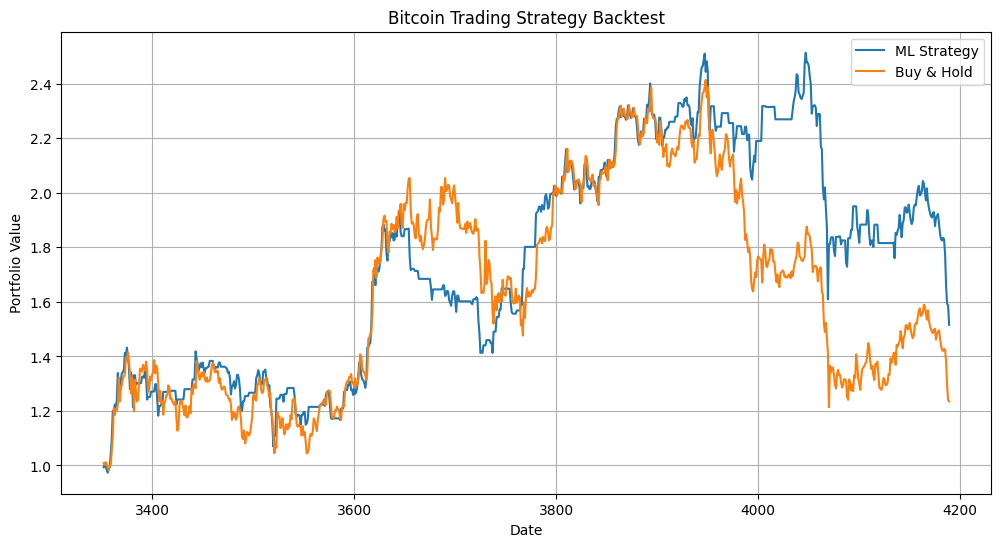

In [420]:
plt.figure(figsize=(12,6))
plt.plot(backtest.index,backtest["Strategy_cummulative"],label="ML Strategy")
plt.plot(backtest.index,backtest["BuyHold_cummulative"],label="Buy & Hold")
plt.title("Bitcoin Trading Strategy Backtest")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.savefig(
    "../figures/strategy_backtest.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [421]:
strategy_return = (
    backtest["Strategy_cummulative"].iloc[-1] - 1
)

buyhold_return = (
    backtest["BuyHold_cummulative"].iloc[-1] - 1
)

print("Strategy Return:", f"{strategy_return:.2%}")
print("Buy & Hold:", f"{buyhold_return:.2%}")

Strategy Return: 51.57%
Buy & Hold: 23.50%


In [422]:
sharpe = (
    np.sqrt(252)
    * backtest["Strategy_Return"].mean()
    / backtest["Strategy_Return"].std()
)

print("Sharpe:", round(sharpe, 2))

Sharpe: 0.54


In [423]:
rolling_max = (
    backtest["Strategy_cummulative"]
    .cummax()
)

drawdown = (
    backtest["Strategy_cummulative"]
    - rolling_max
) / rolling_max

max_drawdown = drawdown.min()

print("Max Drawdown:", f"{max_drawdown:.2%}")

Max Drawdown: -39.71%


In [424]:
win_rate = (
    backtest["Strategy_Return"] > 0
).mean()

print("Win Rate:", f"{win_rate:.2%}")

Win Rate: 33.05%
